# sales_daily 月度预测 + 多预测 offset 误差分析

目标：复现 `code/30d-jenny/01-rolling.ipynb` 的工作日节奏预测方法，在更大的 `data/sales_daily.csv` 数据集上做月度预测、benchmark 和误差 insight。

统一评估口径：月末倒数第 5 个工作日作为锚点，预测月末总量；主指标为月末总量 MAPE，同时展示 `accuracy = 1 - MAPE`。


## Block 1：数据接入、读取、清洗、转换

本 block 对应 `mle-workflow` 的数据契约与可复现要求：先锁字段、日期、粒度和缺失处理，再进入建模。


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import date, timedelta
from pathlib import Path
import importlib.util
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.interpolate import PchipInterpolator
import chinese_calendar as calendar


In [2]:
def load_sales_daily(path: Path) -> pd.DataFrame:
    """Load and validate the daily sales contract."""
    df = pd.read_csv(path)
    missing_cols = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing_cols:
        raise ValueError(f"sales_daily 缺少必要字段: {missing_cols}")

    df = df[REQUIRED_COLUMNS].copy()
    df["transdate"] = pd.to_datetime(df["transdate"], errors="coerce")
    if df["transdate"].isna().any():
        bad = df[df["transdate"].isna()].head()
        raise ValueError(f"transdate 存在无法解析的日期:\n{bad}")

    df["bizym"] = df["bizym"].astype(int)
    df["num_hosp"] = pd.to_numeric(df["num_hosp"], errors="coerce")
    df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
    if df[["num_hosp", "qty"]].isna().any().any():
        raise ValueError("num_hosp 或 qty 存在无法解析的数值")

    expected_bizym = df["transdate"].dt.strftime("%Y%m").astype(int)
    mismatch = df[df["bizym"] != expected_bizym]
    if not mismatch.empty:
        raise ValueError(f"bizym 与 transdate 月份不一致，示例:\n{mismatch.head()}")

    duplicated = df.duplicated(["bizym", "transdate"]).sum()
    if duplicated:
        raise ValueError(f"bizym/transdate 粒度存在重复: {duplicated} 行")

    return df.sort_values(["bizym", "transdate"]).reset_index(drop=True)


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("../../data/sales_daily.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/sales_daily.csv")

REQUIRED_COLUMNS = ["bizym", "transdate", "num_hosp", "qty"]
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

if importlib.util.find_spec("chinese_calendar") is None:
    raise ImportError(
        "缺少依赖 chinese_calendar。请在当前 notebook kernel 中安装："
        "pip install chinese-calendar，或使用项目 requirements.txt 对应环境。"
    )

df_raw = load_sales_daily(DATA_PATH)
df_raw["raw_mtd_qty"] = df_raw.groupby("bizym")["qty"].cumsum()
print(f"data path: {DATA_PATH.resolve()}")
print(f"shape: {df_raw.shape}")
print(f"date range: {df_raw['transdate'].min().date()} ~ {df_raw['transdate'].max().date()}")
print(f"months: {df_raw['bizym'].nunique()} ({df_raw['bizym'].min()} ~ {df_raw['bizym'].max()})")
df_raw.head()


data path: /Users/mark/Git/lab/ts-forecast/data/sales_daily.csv
shape: (1575, 5)
date range: 2022-01-01 ~ 2026-04-30
months: 52 (202201 ~ 202604)


,bizym,transdate,num_hosp,qty,raw_mtd_qty
0,202201,2022-01-01,10,2793.0000,2793.0000
1,202201,2022-01-02,12,4633.0000,7426.0000
2,202201,2022-01-03,69,15154.0000,22580.0000
3,202201,2022-01-04,460,76524.3317,99104.3317
4,202201,2022-01-05,316,47902.5417,147006.8734


In [3]:
def build_calendar(year: int, month: int) -> pd.DataFrame:
    """Generate Chinese business-calendar metadata for one month."""
    start = date(year, month, 1)
    end = date(year + 1, 1, 1) - timedelta(days=1) if month == 12 else date(year, month + 1, 1) - timedelta(days=1)

    records = []
    wd_counter = 0
    prev_wd_date = None
    d = start
    while d <= end:
        is_wd = bool(calendar.is_workday(d))
        if is_wd:
            wd_counter += 1
            prev_wd_date = d
        records.append({
            "transdate": pd.Timestamp(d),
            "day_of_month": d.day,
            "is_workday": is_wd,
            "wd_seq": wd_counter if is_wd else 0,
            "prev_workday": pd.Timestamp(prev_wd_date) if prev_wd_date else pd.NaT,
        })
        d += timedelta(days=1)
    return pd.DataFrame(records)


def preprocess_sales_daily(df: pd.DataFrame, warn: bool = True) -> pd.DataFrame:
    """Fill missing dates, move non-workday activity to nearby workdays, and recompute MTD."""
    filled_parts = []
    total_before = df.groupby("bizym")[["qty", "num_hosp"]].sum()

    for ym, group in df.groupby("bizym", sort=True):
        year, month = divmod(int(ym), 100)
        cal = build_calendar(year, month)
        merged = cal.merge(
            group[["transdate", "qty", "num_hosp"]],
            on="transdate",
            how="left",
        )

        if warn:
            missing_dates = merged.loc[merged["qty"].isna(), "transdate"].dt.date.tolist()
            if missing_dates:
                print(f"[warn] bizym={ym} 缺失日期已补 0: {missing_dates}")

        merged["qty"] = merged["qty"].fillna(0.0)
        merged["num_hosp"] = merged["num_hosp"].fillna(0.0)
        merged["bizym"] = int(ym)

        workday_indices = merged.index[merged["is_workday"]].tolist()
        for idx in merged.index[~merged["is_workday"]]:
            qty_val = merged.at[idx, "qty"]
            hosp_val = merged.at[idx, "num_hosp"]
            if qty_val == 0 and hosp_val == 0:
                continue

            next_wd = [i for i in workday_indices if i > idx]
            prev_wd = [i for i in workday_indices if i < idx]
            if next_wd:
                target_idx = next_wd[0]
            elif prev_wd:
                target_idx = prev_wd[-1]
            else:
                if warn:
                    print(f"[warn] bizym={ym} 月内无工作日，{merged.at[idx, 'transdate'].date()} 无法转移")
                continue

            merged.at[target_idx, "qty"] += qty_val
            merged.at[target_idx, "num_hosp"] += hosp_val
            merged.at[idx, "qty"] = 0.0
            merged.at[idx, "num_hosp"] = 0.0

        merged["mtd_qty"] = merged["qty"].cumsum()
        merged["mtd_num_hosp"] = merged["num_hosp"].cumsum()
        merged["dow"] = merged["transdate"].dt.day_name()
        merged["month"] = merged["transdate"].dt.month
        merged["year"] = merged["transdate"].dt.year
        merged["is_month_end"] = merged["transdate"].dt.is_month_end

        filled_parts.append(merged[[
            "bizym", "transdate", "year", "month", "day_of_month", "dow",
            "is_workday", "wd_seq", "prev_workday", "qty", "num_hosp",
            "mtd_qty", "mtd_num_hosp", "is_month_end",
        ]])

    result = pd.concat(filled_parts, ignore_index=True).sort_values(["bizym", "transdate"]).reset_index(drop=True)
    total_after = result.groupby("bizym")[["qty", "num_hosp"]].sum()
    if not np.allclose(total_before["qty"].sort_index(), total_after["qty"].sort_index()):
        raise AssertionError("预处理前后月度 qty 总量不守恒")
    if not np.allclose(total_before["num_hosp"].sort_index(), total_after["num_hosp"].sort_index()):
        raise AssertionError("预处理前后月度 num_hosp 总量不守恒")
    return result


df = preprocess_sales_daily(df_raw, warn=True)
print(df.shape)
df.head()


[warn] bizym=202202 缺失日期已补 0: [datetime.date(2022, 2, 2)]
[warn] bizym=202402 缺失日期已补 0: [datetime.date(2024, 2, 10), datetime.date(2024, 2, 11), datetime.date(2024, 2, 12)]
[warn] bizym=202602 缺失日期已补 0: [datetime.date(2026, 2, 16), datetime.date(2026, 2, 17)]


(1581, 14)


,bizym,transdate,year,month,day_of_month,dow,is_workday,wd_seq,prev_workday,qty,num_hosp,mtd_qty,mtd_num_hosp,is_month_end
0,202201,2022-01-01,2022,1,1,Saturday,False,0,NaT,0.0000,0.0000,0.0000,0.0000,False
1,202201,2022-01-02,2022,1,2,Sunday,False,0,NaT,0.0000,0.0000,0.0000,0.0000,False
2,202201,2022-01-03,2022,1,3,Monday,False,0,NaT,0.0000,0.0000,0.0000,0.0000,False
3,202201,2022-01-04,2022,1,4,Tuesday,True,1,2022-01-04,99104.3317,551.0000,99104.3317,551.0000,False
4,202201,2022-01-05,2022,1,5,Wednesday,True,2,2022-01-05,47902.5417,316.0000,147006.8734,867.0000,False


## Block 2：数据分析

本 block 对应 `exploratory-data-analysis` 与 `python-eda`：先看结构、质量、分布、时间趋势，再进入特征与建模。


In [4]:
quality_summary = pd.DataFrame({
    "metric": [
        "raw_rows", "processed_rows", "raw_months", "raw_duplicate_rows",
        "raw_missing_values", "raw_negative_qty_rows", "raw_nonpositive_hosp_rows",
        "processed_missing_values",
    ],
    "value": [
        len(df_raw), len(df), df_raw["bizym"].nunique(), df_raw.duplicated().sum(),
        int(df_raw[REQUIRED_COLUMNS].isna().sum().sum()), int((df_raw["qty"] < 0).sum()),
        int((df_raw["num_hosp"] <= 0).sum()), int(df.isna().sum().sum()),
    ],
})
quality_summary

,metric,value
0,raw_rows,1575
1,processed_rows,1581
2,raw_months,52
3,raw_duplicate_rows,0
4,raw_missing_values,0
5,raw_negative_qty_rows,2
6,raw_nonpositive_hosp_rows,0
7,processed_missing_values,81


In [5]:
full_dates = pd.date_range(df_raw["transdate"].min(), df_raw["transdate"].max(), freq="D")
missing_calendar_dates = full_dates.difference(pd.DatetimeIndex(df_raw["transdate"]))
print(f"缺失自然日数量: {len(missing_calendar_dates)}")
print([d.strftime("%Y-%m-%d") for d in missing_calendar_dates])
print("\n负 qty 行:")
display(df_raw[df_raw["qty"] < 0])

monthly_raw = df_raw.groupby("bizym").agg(
    days=("transdate", "size"),
    start=("transdate", "min"),
    end=("transdate", "max"),
    month_total=("qty", "sum"),
    hosp_total=("num_hosp", "sum"),
    min_daily_qty=("qty", "min"),
    max_daily_qty=("qty", "max"),
).reset_index()
monthly_raw["qty_per_hosp"] = monthly_raw["month_total"] / monthly_raw["hosp_total"]
monthly_raw["mom_qty_pct"] = monthly_raw["month_total"].pct_change() * 100
monthly_raw["yoy_qty_pct"] = monthly_raw["month_total"].pct_change(12) * 100
monthly_raw.tail(12)


缺失自然日数量: 6
['2022-02-02', '2024-02-10', '2024-02-11', '2024-02-12', '2026-02-16', '2026-02-17']

负 qty 行:


,bizym,transdate,num_hosp,qty,raw_mtd_qty
55,202202,2022-02-26,16,-83.0000,759384.2450
728,202312,2023-12-31,2,-60.0000,1977926.0000


,bizym,days,start,end,month_total,hosp_total,min_daily_qty,max_daily_qty,qty_per_hosp,mom_qty_pct,yoy_qty_pct
40,202505,31,2025-05-01,2025-05-31,2008992.0000,11595,100.0000,184947.0000,173.2636,-7.6751,6.9926
41,202506,30,2025-06-01,2025-06-30,2394239.0000,12856,465.0000,295226.0000,186.2351,19.1761,19.0457
42,202507,31,2025-07-01,2025-07-31,2264622.0000,13960,449.0000,169016.0000,162.2222,-5.4137,6.8011
43,202508,31,2025-08-01,2025-08-31,2322179.0000,13651,1219.0000,203889.0000,170.1105,2.5416,7.5881
44,202509,30,2025-09-01,2025-09-30,3069649.0000,16241,1282.0000,228846.0000,189.0062,32.1883,20.9201
45,202510,31,2025-10-01,2025-10-31,2104318.0000,12263,34.0000,184612.0000,171.5990,-31.4476,6.0877
46,202511,30,2025-11-01,2025-11-30,2384335.0000,13799,359.0000,248471.0000,172.7904,13.3068,8.5395
47,202512,31,2025-12-01,2025-12-31,2812283.0000,15799,628.0000,216082.0000,178.0039,17.9483,17.9221
48,202601,31,2026-01-01,2026-01-31,2842656.0000,15115,1143.0000,201550.0000,188.0685,1.0800,14.8439
49,202602,26,2026-02-01,2026-02-28,1792965.0000,10280,208.0000,267842.0000,174.4129,-36.9264,12.4922


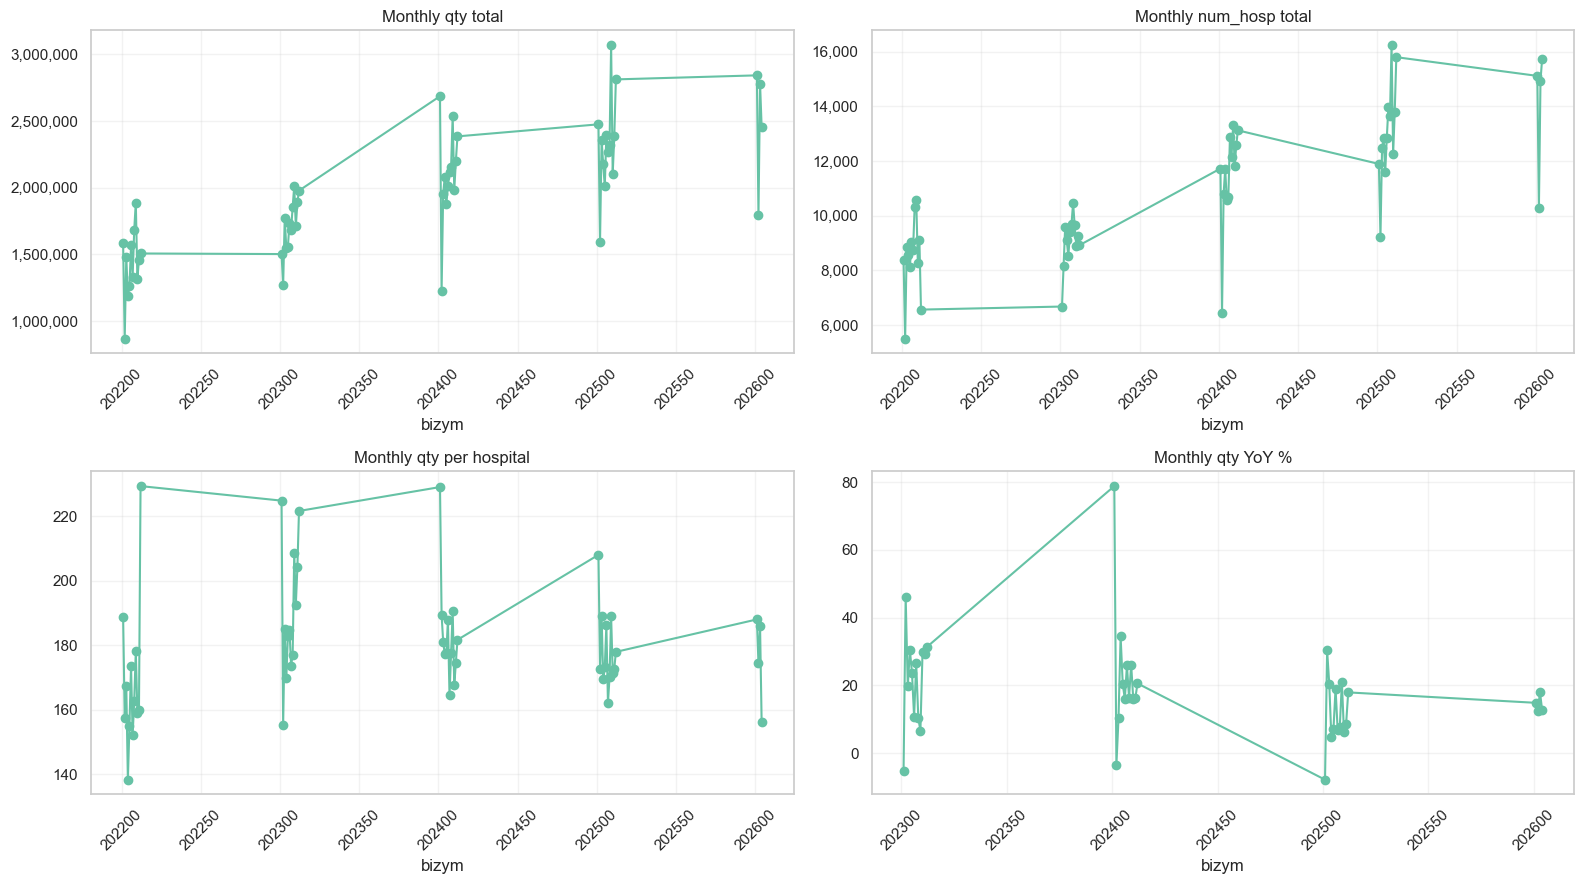

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
monthly_raw.plot(x="bizym", y="month_total", marker="o", ax=axes[0, 0], legend=False, title="Monthly qty total")
monthly_raw.plot(x="bizym", y="hosp_total", marker="o", ax=axes[0, 1], legend=False, title="Monthly num_hosp total")
monthly_raw.plot(x="bizym", y="qty_per_hosp", marker="o", ax=axes[1, 0], legend=False, title="Monthly qty per hospital")
monthly_raw.plot(x="bizym", y="yoy_qty_pct", marker="o", ax=axes[1, 1], legend=False, title="Monthly qty YoY %")
for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=45)
    if ax.get_ylabel() != "yoy_qty_pct":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


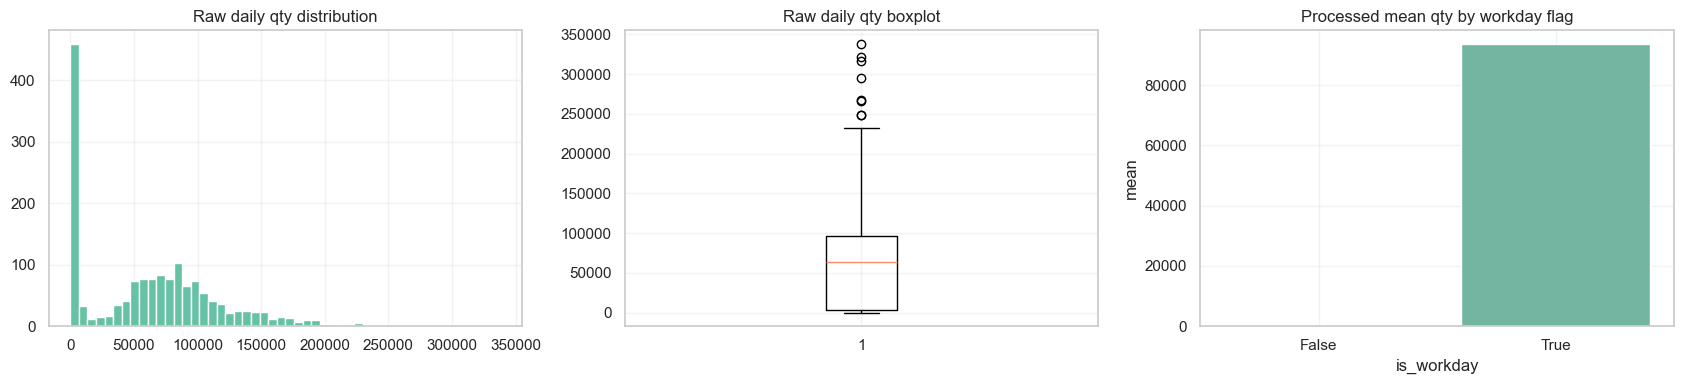

,is_workday,count,mean,median,sum
0,False,504,0.0000,0.0000,0.0000
1,True,1077,93488.0273,84032.0000,100686605.3729


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(df_raw["qty"], bins=50, edgecolor="white")
axes[0].set_title("Raw daily qty distribution")
axes[1].boxplot(df_raw["qty"], vert=True)
axes[1].set_title("Raw daily qty boxplot")
workday_qty = df.groupby("is_workday")["qty"].agg(["count", "mean", "median", "sum"]).reset_index()
sns.barplot(data=workday_qty, x="is_workday", y="mean", ax=axes[2])
axes[2].set_title("Processed mean qty by workday flag")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
workday_qty


,count,mean,median,sum
dow,,,,
Monday,224,128322.1031,134851.0000,28744151.0865
Tuesday,225,95112.8783,95256.1667,21400397.6166
Wednesday,225,76374.3892,76089.0000,17184237.5766
Thursday,226,76030.7011,75149.0000,17182938.4465
Friday,225,60796.4025,60396.0000,13679190.5633
Saturday,225,4105.0302,1403.0000,923631.7917
Sunday,225,6986.9257,1716.0000,1572058.2917


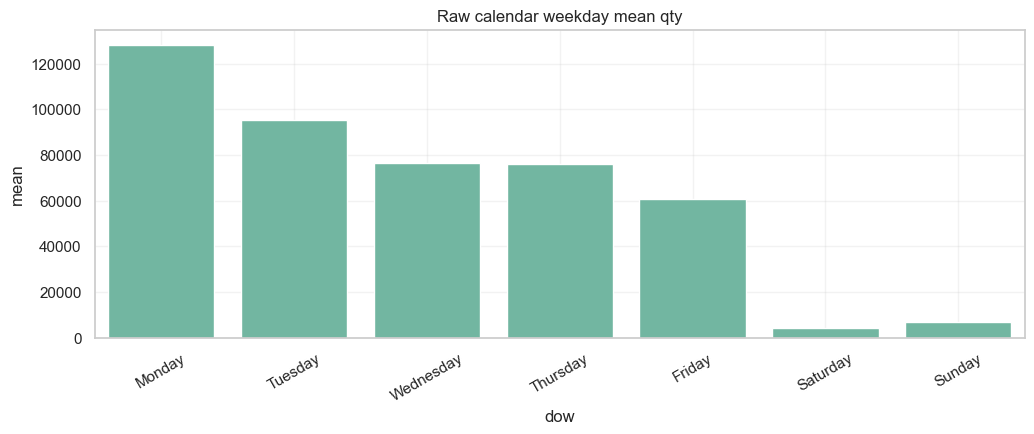

In [8]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_stats = df_raw.assign(dow=df_raw["transdate"].dt.day_name()).groupby("dow")["qty"].agg(["count", "mean", "median", "sum"]).reindex(weekday_order)
display(weekday_stats)

plt.figure(figsize=(12, 4))
sns.barplot(data=weekday_stats.reset_index(), x="dow", y="mean", order=weekday_order)
plt.title("Raw calendar weekday mean qty")
plt.xticks(rotation=30)
plt.grid(alpha=0.25)
plt.show()


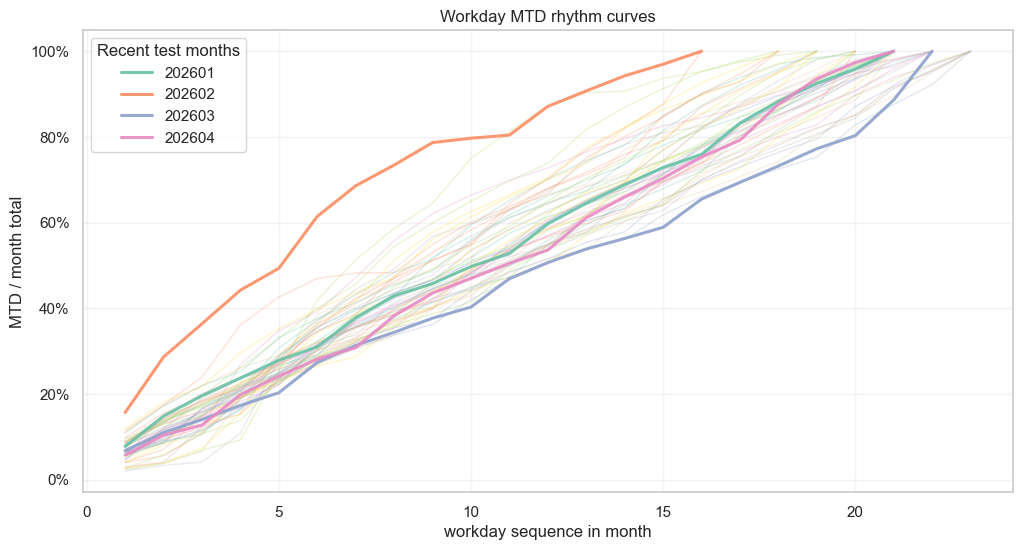

In [9]:
# 工作日节奏形态：每个月的工作日累计占比曲线
rhythm_preview = []
for ym, g in df.groupby("bizym"):
    total = g["mtd_qty"].iloc[-1]
    if total == 0:
        continue
    temp = g[g["wd_seq"] > 0][["bizym", "wd_seq", "mtd_qty"]].copy()
    temp["rhythm"] = temp["mtd_qty"] / total
    rhythm_preview.append(temp)
rhythm_preview = pd.concat(rhythm_preview, ignore_index=True)

plt.figure(figsize=(12, 6))
for ym, sub in rhythm_preview.groupby("bizym"):
    alpha = 0.25 if ym < 202601 else 0.9
    lw = 1 if ym < 202601 else 2.2
    plt.plot(sub["wd_seq"], sub["rhythm"], alpha=alpha, linewidth=lw, label=str(ym) if ym >= 202601 else None)
plt.title("Workday MTD rhythm curves")
plt.xlabel("workday sequence in month")
plt.ylabel("MTD / month total")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend(title="Recent test months")
plt.grid(alpha=0.25)
plt.show()


## Block 3：数据挖掘 + 特征工程

核心实体粒度为“目标年月 + 预测锚点”。所有特征只使用锚点及之前的目标月事实、以及目标月之前已经完成的历史同月数据。


In [10]:
# Block 3 parameters
# 1-3: train / valid / test month ranges. Use inclusive YYYYMM integers.
TRAIN_YM_RANGE = (202401, 202412)
VALID_YM_RANGE = (202501, 202512)
TEST_YM_RANGE = (202601, 202604)
# 4: Forecast timing. Each value means the N-th workday from month end.
FORECAST_WORKDAY_OFFSETS = [5, 10]
# 5: Write split feature + target tables for downstream baseline benchmarks.
WRITE_FEATURE_TARGET_CSV = True
SPLIT_RANGES = {
    "train": TRAIN_YM_RANGE,
    "valid": VALID_YM_RANGE,
    "test": TEST_YM_RANGE,
}
CSV_OUTPUT_DIR = Path(".")
if not (CSV_OUTPUT_DIR / "eda.ipynb").exists() and (Path("code") / "30d-jenny" / "eda.ipynb").exists():
    CSV_OUTPUT_DIR = Path("code") / "30d-jenny"

if not FORECAST_WORKDAY_OFFSETS:
    raise ValueError("FORECAST_WORKDAY_OFFSETS 不能为空")
if len(set(FORECAST_WORKDAY_OFFSETS)) != len(FORECAST_WORKDAY_OFFSETS):
    raise ValueError(f"FORECAST_WORKDAY_OFFSETS 存在重复值: {FORECAST_WORKDAY_OFFSETS}")
if any((not isinstance(offset, int)) or offset <= 0 for offset in FORECAST_WORKDAY_OFFSETS):
    raise ValueError(f"FORECAST_WORKDAY_OFFSETS 必须是正整数 list: {FORECAST_WORKDAY_OFFSETS}")

In [11]:
def month_add(ym: int, delta_months: int) -> int:
    y, m = divmod(int(ym), 100)
    idx = y * 12 + (m - 1) + delta_months
    return (idx // 12) * 100 + (idx % 12 + 1)


def get_forecast_anchor(bizym: int, forecast_offset: int) -> dict:
    year, month = divmod(int(bizym), 100)
    cal = build_calendar(year, month)
    wds = cal[cal["is_workday"]].copy()
    forecast_offset = int(forecast_offset)
    if forecast_offset <= 0:
        raise ValueError(f"forecast_offset 必须为正整数: {forecast_offset}")
    if len(wds) < forecast_offset:
        raise ValueError(f"{bizym} 工作日少于 {forecast_offset} 天")
    anchor = wds.iloc[-forecast_offset]
    return {
        "bizym": int(bizym),
        "forecast_offset": forecast_offset,
        "anchor_date": anchor["transdate"],
        "forecast_start_date": anchor["transdate"] + pd.Timedelta(days=1),
        "anchor_wd_seq": int(anchor["wd_seq"]),
        "max_wd_seq": int(wds["wd_seq"].max()),
        "remaining_workdays_after_anchor": forecast_offset - 1,
    }

def calc_wd_rhythm(data: pd.DataFrame, bizym: int) -> pd.DataFrame:
    month_df = data[data["bizym"] == int(bizym)].copy()
    if month_df.empty:
        return pd.DataFrame(columns=["wd_seq", "rhythm"])
    total = float(month_df["mtd_qty"].iloc[-1])
    if total == 0 or pd.isna(total):
        return pd.DataFrame(columns=["wd_seq", "rhythm"])
    wd_df = month_df[month_df["wd_seq"] > 0].copy()
    wd_df["rhythm"] = wd_df["mtd_qty"] / total
    return wd_df[["wd_seq", "rhythm"]].reset_index(drop=True)


def align_rhythm(src_rhythm: pd.Series, target_max_wd: int, method: str = "linear", extrapolate_wds: int = 3) -> np.ndarray:
    src_rhythm = src_rhythm.dropna().sort_index()
    src_max_wd = len(src_rhythm)
    if src_max_wd == 0:
        return np.full(target_max_wd, np.nan)
    if src_max_wd == target_max_wd:
        return src_rhythm.values.copy()

    if method == "linear":
        x_old = np.linspace(0, 1, src_max_wd)
        x_new = np.linspace(0, 1, target_max_wd)
        aligned = np.interp(x_new, x_old, src_rhythm.values)
    elif method == "pchip":
        x_old = np.arange(1, src_max_wd + 1, dtype=float)
        interp_fn = PchipInterpolator(x_old, src_rhythm.values)
        if target_max_wd < src_max_wd:
            x_new = np.linspace(1, src_max_wd, target_max_wd)
            aligned = interp_fn(x_new)
        else:
            aligned_known = interp_fn(np.linspace(1, src_max_wd, src_max_wd))
            tail = src_rhythm.values[-max(2, min(extrapolate_wds, src_max_wd)):]
            avg_increment = float(np.mean(np.diff(tail))) if len(tail) > 1 else 0.0
            extra = np.array([aligned_known[-1] + avg_increment * (i + 1) for i in range(target_max_wd - src_max_wd)])
            extra = np.clip(extra, aligned_known[-1], 1.0)
            aligned = np.concatenate([aligned_known, extra])
    else:
        raise ValueError(f"unknown rhythm alignment method: {method}")

    return np.maximum.accumulate(np.clip(aligned, 0, 1))


def blend_rhythm(
    data: pd.DataFrame,
    history_yms: list[int],
    weights: list[float],
    target_max_wd: int,
    method: str = "linear",
) -> pd.Series:
    if len(history_yms) != len(weights):
        raise ValueError("history_yms 与 weights 长度必须一致")
    blended = np.zeros(target_max_wd, dtype=float)
    valid_weight_sum = 0.0

    for ym, weight in zip(history_yms, weights):
        rhythm_df = calc_wd_rhythm(data, ym)
        if rhythm_df.empty:
            continue
        src = rhythm_df.set_index("wd_seq")["rhythm"]
        aligned = align_rhythm(src, target_max_wd=target_max_wd, method=method)
        if np.isnan(aligned).all():
            continue
        blended += float(weight) * aligned
        valid_weight_sum += float(weight)

    if valid_weight_sum == 0:
        return pd.Series(dtype=float)
    blended = np.maximum.accumulate(np.clip(blended / valid_weight_sum, 0, 1))
    return pd.Series(blended, index=range(1, target_max_wd + 1), name="blended_rhythm")


In [12]:
def estimate_month_total(
    data: pd.DataFrame,
    target_ym: int,
    anchor_date: pd.Timestamp,
    blended_rhythm: pd.Series,
    lookback_wds: int = 3,
) -> float:
    month_df = data[data["bizym"] == int(target_ym)].copy()
    known = month_df[month_df["transdate"] <= pd.Timestamp(anchor_date)]
    known_wds = known[known["wd_seq"] > 0].tail(lookback_wds)
    estimates = []
    for _, row in known_wds.iterrows():
        wd_seq = int(row["wd_seq"])
        rhythm = blended_rhythm.get(wd_seq, np.nan)
        if pd.notna(rhythm) and rhythm > 0:
            estimates.append(float(row["mtd_qty"]) / float(rhythm))
    if not estimates:
        return np.nan
    return float(np.median(estimates))


def forecast_mtd(
    data: pd.DataFrame,
    target_ym: int,
    forecast_start_date: pd.Timestamp,
    blended_rhythm: pd.Series,
    lookback_wds: int = 3,
) -> pd.DataFrame:
    year, month = divmod(int(target_ym), 100)
    cal = build_calendar(year, month)
    forecast_start_date = pd.Timestamp(forecast_start_date)
    anchor_date = forecast_start_date - pd.Timedelta(days=1)
    anchor_row = data[(data["bizym"] == int(target_ym)) & (data["transdate"] == anchor_date)]
    if anchor_row.empty:
        raise ValueError(f"找不到锚点日期 {anchor_date.date()} 的数据")
    anchor_mtd = float(anchor_row["mtd_qty"].iloc[0])

    month_total = estimate_month_total(data, target_ym, anchor_date, blended_rhythm, lookback_wds=lookback_wds)
    if pd.isna(month_total):
        raise ValueError(f"{target_ym} 无法估算月末总量")

    forecast_dates = cal[cal["transdate"] >= forecast_start_date].copy()
    records = []
    prev_predicted_mtd = anchor_mtd
    for _, row in forecast_dates.iterrows():
        if bool(row["is_workday"]):
            rhythm = blended_rhythm.get(int(row["wd_seq"]), np.nan)
            predicted_mtd = prev_predicted_mtd if pd.isna(rhythm) else month_total * float(rhythm)
            predicted_mtd = max(predicted_mtd, prev_predicted_mtd)
            prev_predicted_mtd = predicted_mtd
        else:
            predicted_mtd = prev_predicted_mtd
        records.append({
            "transdate": row["transdate"],
            "day_of_month": int(row["day_of_month"]),
            "is_workday": bool(row["is_workday"]),
            "wd_seq": int(row["wd_seq"]),
            "predicted_mtd_qty": round(predicted_mtd),
        })
    result = pd.DataFrame(records)
    all_mtd = [anchor_mtd] + result["predicted_mtd_qty"].tolist()
    result["predicted_daily_qty"] = [max(0, all_mtd[i] - all_mtd[i - 1]) for i in range(1, len(all_mtd))]
    return result


def decompose_from_month_total(
    data: pd.DataFrame,
    target_ym: int,
    forecast_start_date: pd.Timestamp,
    month_total: float,
    blended_rhythm: pd.Series,
) -> pd.DataFrame:
    year, month = divmod(int(target_ym), 100)
    cal = build_calendar(year, month)
    forecast_start_date = pd.Timestamp(forecast_start_date)
    anchor_date = forecast_start_date - pd.Timedelta(days=1)
    anchor_row = data[(data["bizym"] == int(target_ym)) & (data["transdate"] == anchor_date)]
    if anchor_row.empty:
        raise ValueError(f"找不到锚点日期 {anchor_date.date()} 的数据")
    anchor_mtd = float(anchor_row["mtd_qty"].iloc[0])
    if month_total <= anchor_mtd:
        raise ValueError("month_total 不能小于锚点 MTD")

    anchor_cal = cal[cal["transdate"] == anchor_date]
    if bool(anchor_cal["is_workday"].iloc[0]):
        anchor_wd_seq = int(anchor_cal["wd_seq"].iloc[0])
    else:
        prev_wd = anchor_cal["prev_workday"].iloc[0]
        anchor_wd_seq = int(cal.loc[cal["transdate"] == prev_wd, "wd_seq"].iloc[0])

    anchor_rhythm = blended_rhythm.get(anchor_wd_seq, np.nan)
    if pd.isna(anchor_rhythm) or anchor_rhythm >= 1.0:
        raise ValueError(f"锚点节奏值异常: wd_seq={anchor_wd_seq}, rhythm={anchor_rhythm}")

    result = cal[cal["transdate"] >= forecast_start_date].copy()
    remaining = month_total - anchor_mtd
    remaining_span = 1.0 - float(anchor_rhythm)
    wd_mask = result["is_workday"]
    future_r = result.loc[wd_mask, "wd_seq"].map(blended_rhythm)
    result.loc[wd_mask, "predicted_mtd_qty"] = anchor_mtd + (future_r - anchor_rhythm) / remaining_span * remaining
    result["predicted_mtd_qty"] = result["predicted_mtd_qty"].ffill().fillna(anchor_mtd).round().astype(int)
    all_mtd = [anchor_mtd] + result["predicted_mtd_qty"].tolist()
    result["predicted_daily_qty"] = [max(0, all_mtd[i] - all_mtd[i - 1]) for i in range(1, len(all_mtd))]
    return result[["transdate", "day_of_month", "is_workday", "wd_seq", "predicted_mtd_qty", "predicted_daily_qty"]].reset_index(drop=True)


In [13]:
monthly = df.groupby("bizym").agg(
    actual_month_total=("qty", "sum"),
    workdays=("is_workday", "sum"),
    days=("transdate", "size"),
).reset_index()
monthly["prev_year_ym"] = monthly["bizym"].map(lambda x: month_add(x, -12))
monthly["prev_2year_ym"] = monthly["bizym"].map(lambda x: month_add(x, -24))
month_set = set(monthly["bizym"])
monthly["has_y1_y2_history"] = monthly.apply(lambda r: r["prev_year_ym"] in month_set and r["prev_2year_ym"] in month_set, axis=1)

anchors = pd.DataFrame([
    get_forecast_anchor(ym, forecast_offset)
    for ym in monthly["bizym"]
    for forecast_offset in FORECAST_WORKDAY_OFFSETS
])
feature_panel = monthly.merge(anchors, on="bizym", how="left")
anchor_mtd = df[["bizym", "transdate", "mtd_qty", "mtd_num_hosp"]].rename(columns={
    "transdate": "anchor_date",
    "mtd_qty": "anchor_mtd_qty",
    "mtd_num_hosp": "anchor_mtd_num_hosp",
})
feature_panel = feature_panel.merge(anchor_mtd, on=["bizym", "anchor_date"], how="left")
split_conditions = [feature_panel["bizym"].between(start_ym, end_ym) for start_ym, end_ym in SPLIT_RANGES.values()]
feature_panel["split"] = np.select(
    split_conditions,
    list(SPLIT_RANGES.keys()),
    default="not_used",
)
feature_panel = feature_panel[feature_panel["has_y1_y2_history"]].reset_index(drop=True)

# Only export target plus fields observable at the forecast anchor. Do not export
# month-end-derived analysis columns or post-anchor actuals.
EXPORT_COLUMNS = [
    "bizym", "forecast_offset", "actual_month_total", "workdays", "days",
    "prev_year_ym", "prev_2year_ym", "has_y1_y2_history", "anchor_date",
    "forecast_start_date", "anchor_wd_seq", "max_wd_seq", "remaining_workdays_after_anchor",
    "anchor_mtd_qty", "anchor_mtd_num_hosp", "split",
]
feature_panel = feature_panel[EXPORT_COLUMNS].copy()

print(f"feature_panel shape: {feature_panel.shape}")
print("feature_panel columns:")
display(pd.DataFrame({
    "column": feature_panel.columns,
    "dtype": [feature_panel[col].dtype for col in feature_panel.columns],
    "missing_count": [feature_panel[col].isna().sum() for col in feature_panel.columns],
    "missing_pct": [feature_panel[col].isna().mean() * 100 for col in feature_panel.columns],
}))

if WRITE_FEATURE_TARGET_CSV:
    CSV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    export_panel = feature_panel[feature_panel["split"].isin(SPLIT_RANGES.keys())].copy()
    for split_name in SPLIT_RANGES:
        output_path = CSV_OUTPUT_DIR / f"{split_name}.csv"
        split_df = export_panel[export_panel["split"] == split_name].sort_values(["bizym", "forecast_offset"])
        split_df.to_csv(output_path, index=False)
        print(f"wrote {output_path}: {split_df.shape[0]} rows, {split_df.shape[1]} columns")


feature_panel shape: (56, 16)
feature_panel columns:


,column,dtype,missing_count,missing_pct
0,bizym,int64,0,0.0000
1,forecast_offset,int64,0,0.0000
2,actual_month_total,float64,0,0.0000
3,workdays,int64,0,0.0000
4,days,int64,0,0.0000
5,prev_year_ym,int64,0,0.0000
6,prev_2year_ym,int64,0,0.0000
7,has_y1_y2_history,bool,0,0.0000
8,anchor_date,datetime64[ns],0,0.0000
9,forecast_start_date,datetime64[ns],0,0.0000


wrote train.csv: 24 rows, 16 columns
wrote valid.csv: 24 rows, 16 columns
wrote test.csv: 8 rows, 16 columns


In [14]:
display(feature_panel.head(15)) # 全部导出列

,bizym,forecast_offset,actual_month_total,workdays,days,prev_year_ym,prev_2year_ym,has_y1_y2_history,anchor_date,forecast_start_date,anchor_wd_seq,max_wd_seq,remaining_workdays_after_anchor,anchor_mtd_qty,anchor_mtd_num_hosp,split
0,202401,5,2686281.0000,22,31,202301,202201,True,2024-01-25,2024-01-26,18,22,4,2290259.0000,9991.0000,train
1,202401,10,2686281.0000,22,31,202301,202201,True,2024-01-18,2024-01-19,13,22,9,1724476.0000,7371.0000,train
2,202402,5,1223031.0000,18,29,202302,202202,True,2024-02-23,2024-02-24,14,18,4,917906.0000,4838.0000,train
3,202402,10,1223031.0000,18,29,202302,202202,True,2024-02-18,2024-02-19,9,18,9,670958.0000,3077.0000,train
4,202403,5,1955574.0000,21,31,202303,202203,True,2024-03-25,2024-03-26,17,21,4,1608772.0000,9107.0000,train
5,202403,10,1955574.0000,21,31,202303,202203,True,2024-03-18,2024-03-19,12,21,9,1177165.0000,6681.0000,train
6,202404,5,2077981.0000,22,30,202304,202204,True,2024-04-25,2024-04-26,18,22,4,1768946.0000,10075.0000,train
7,202404,10,2077981.0000,22,30,202304,202204,True,2024-04-18,2024-04-19,13,22,9,1267439.0000,7235.0000,train
8,202405,5,1877693.0000,21,31,202305,202205,True,2024-05-27,2024-05-28,17,21,4,1589318.0000,9053.0000,train
9,202405,10,1877693.0000,21,31,202305,202205,True,2024-05-20,2024-05-21,12,21,9,1164507.0000,6556.0000,train


## Block 4：特征选择 + 模型选择

严格复现原 notebook 的方法族：用历史同月工作日节奏反推月末总量。候选只比较节奏插值方式、历史权重和锚点前回看工作日数。


In [15]:
@dataclass(frozen=True)
class RhythmConfig:
    name: str
    method: str
    weight_y1: float
    weight_y2: float
    lookback_wds: int

    @property
    def weights(self) -> list[float]:
        return [self.weight_y1, self.weight_y2]


CONFIGS = [
    RhythmConfig("linear_w70_30_lb3", "linear", 0.7, 0.3, 3),
    RhythmConfig("linear_w50_50_lb3", "linear", 0.5, 0.5, 3),
    RhythmConfig("linear_w30_70_lb3", "linear", 0.3, 0.7, 3),
    RhythmConfig("linear_w70_30_lb1", "linear", 0.7, 0.3, 1),
    RhythmConfig("linear_w70_30_lb5", "linear", 0.7, 0.3, 5),
    RhythmConfig("pchip_w70_30_lb3", "pchip", 0.7, 0.3, 3),
    RhythmConfig("pchip_w50_50_lb3", "pchip", 0.5, 0.5, 3),
]


def evaluate_single_forecast(data: pd.DataFrame, target_ym: int, anchor_date: pd.Timestamp, forecast_df: pd.DataFrame, model_name: str) -> dict:
    actual = data[data["bizym"] == int(target_ym)].copy()
    actual_month_total = float(actual["mtd_qty"].iloc[-1])
    anchor_actual_mtd = float(actual.loc[actual["transdate"] == pd.Timestamp(anchor_date), "mtd_qty"].iloc[0])
    predicted_month_total = float(forecast_df["predicted_mtd_qty"].iloc[-1])
    actual_remaining = actual_month_total - anchor_actual_mtd
    predicted_remaining = predicted_month_total - anchor_actual_mtd

    merged = forecast_df.merge(
        actual[["transdate", "mtd_qty", "qty"]].rename(columns={"mtd_qty": "actual_mtd", "qty": "actual_daily_qty"}),
        on="transdate",
        how="left",
    ).dropna(subset=["actual_mtd"])
    post_anchor_mtd_mape = np.nan
    post_anchor_daily_mape = np.nan
    if not merged.empty:
        denom_mtd = merged["actual_mtd"].replace(0, np.nan)
        post_anchor_mtd_mape = float(((merged["predicted_mtd_qty"] - merged["actual_mtd"]).abs() / denom_mtd).mean() * 100)
        denom_daily = merged["actual_daily_qty"].replace(0, np.nan)
        post_anchor_daily_mape = float(((merged["predicted_daily_qty"] - merged["actual_daily_qty"]).abs() / denom_daily).mean() * 100)

    month_total_mape_pct = abs(predicted_month_total - actual_month_total) / actual_month_total * 100
    return {
        "model_name": model_name,
        "bizym": int(target_ym),
        "anchor_date": pd.Timestamp(anchor_date),
        "predicted_month_total": predicted_month_total,
        "actual_month_total": actual_month_total,
        "month_total_error": predicted_month_total - actual_month_total,
        "month_total_error_pct": (predicted_month_total - actual_month_total) / actual_month_total * 100,
        "month_total_mape_pct": month_total_mape_pct,
        "month_total_accuracy_pct": 100 - month_total_mape_pct,
        "anchor_actual_mtd": anchor_actual_mtd,
        "anchor_completion_pct": anchor_actual_mtd / actual_month_total * 100,
        "predicted_remaining": predicted_remaining,
        "actual_remaining": actual_remaining,
        "remaining_error_pct": ((predicted_remaining - actual_remaining) / actual_remaining * 100) if actual_remaining > 0 else np.nan,
        "post_anchor_mtd_mape_pct": post_anchor_mtd_mape,
        "post_anchor_daily_mape_pct": post_anchor_daily_mape,
    }


def run_offset_backtest(data: pd.DataFrame, panel: pd.DataFrame, configs: list[RhythmConfig]) -> tuple[pd.DataFrame, dict[tuple[str, int, int], pd.DataFrame]]:
    records = []
    forecast_store = {}
    for _, row in panel.iterrows():
        target_ym = int(row["bizym"])
        forecast_offset = int(row["forecast_offset"])
        if row["split"] == "not_used":
            continue
        history_yms = [month_add(target_ym, -12), month_add(target_ym, -24)]
        for cfg in configs:
            blended = blend_rhythm(
                data,
                history_yms=history_yms,
                weights=cfg.weights,
                target_max_wd=int(row["max_wd_seq"]),
                method=cfg.method,
            )
            if blended.empty:
                continue
            try:
                fdf = forecast_mtd(
                    data,
                    target_ym=target_ym,
                    forecast_start_date=row["forecast_start_date"],
                    blended_rhythm=blended,
                    lookback_wds=cfg.lookback_wds,
                )
            except ValueError as exc:
                records.append({"model_name": cfg.name, "bizym": target_ym, "forecast_offset": forecast_offset, "error": str(exc)})
                continue
            anchor_date = pd.Timestamp(row["anchor_date"])
            rec = evaluate_single_forecast(data, target_ym, anchor_date, fdf, cfg.name)
            rec.update({
                "split": row["split"],
                "forecast_offset": forecast_offset,
                "anchor_wd_seq": int(row["anchor_wd_seq"]),
                "max_wd_seq": int(row["max_wd_seq"]),
                "method": cfg.method,
                "weight_y1": cfg.weight_y1,
                "weight_y2": cfg.weight_y2,
                "lookback_wds": cfg.lookback_wds,
            })
            records.append(rec)
            forecast_store[(cfg.name, target_ym, forecast_offset)] = fdf
    return pd.DataFrame(records), forecast_store


eval_all, forecast_store = run_offset_backtest(df, feature_panel, CONFIGS)
metric_cols = ["model_name", "split", "forecast_offset", "bizym", "month_total_mape_pct", "month_total_accuracy_pct", "remaining_error_pct", "post_anchor_mtd_mape_pct"]
eval_all[metric_cols].head()


,model_name,split,forecast_offset,bizym,month_total_mape_pct,month_total_accuracy_pct,remaining_error_pct,post_anchor_mtd_mape_pct
0,linear_w70_30_lb3,train,5,202401,10.0817,89.9183,-68.3861,5.7867
1,linear_w50_50_lb3,train,5,202401,10.1494,89.8506,-68.8449,5.4815
2,linear_w30_70_lb3,train,5,202401,10.2170,89.7830,-69.3032,5.1768
3,linear_w70_30_lb1,train,5,202401,8.7099,91.2901,-59.0806,4.3493
4,linear_w70_30_lb5,train,5,202401,12.4753,87.5247,-84.6218,7.1968


In [16]:
model_summary = eval_all.groupby(["split", "forecast_offset", "model_name"]).agg(
    n_samples=("bizym", "size"),
    n_months=("bizym", "nunique"),
    mean_mape=("month_total_mape_pct", "mean"),
    median_mape=("month_total_mape_pct", "median"),
    mean_accuracy=("month_total_accuracy_pct", "mean"),
    mean_post_anchor_mtd_mape=("post_anchor_mtd_mape_pct", "mean"),
).reset_index().sort_values(["split", "forecast_offset", "mean_mape"])
display(model_summary)

valid_rank = model_summary[model_summary["split"] == "valid"].sort_values("mean_mape")
best_model_name = valid_rank.iloc[0]["model_name"]
best_offset = int(valid_rank.iloc[0]["forecast_offset"])
best_cfg = next(cfg for cfg in CONFIGS if cfg.name == best_model_name)
print(f"Best model selected by valid mean month-total MAPE: {best_model_name}, offset={best_offset}")
valid_rank.head(5)


,split,forecast_offset,model_name,n_samples,n_months,mean_mape,median_mape,mean_accuracy,mean_post_anchor_mtd_mape
2,test,5,linear_w70_30_lb1,4,4,10.3232,7.3867,89.6768,6.6875
0,test,5,linear_w30_70_lb3,4,4,10.4443,7.9242,89.5557,7.0829
1,test,5,linear_w50_50_lb3,4,4,10.6829,8.2649,89.3171,7.4079
3,test,5,linear_w70_30_lb3,4,4,10.9051,8.5505,89.0949,7.7229
5,test,5,pchip_w50_50_lb3,4,4,13.0432,12.6632,86.9568,7.9815
4,test,5,linear_w70_30_lb5,4,4,13.1569,8.6644,86.8431,9.4393
6,test,5,pchip_w70_30_lb3,4,4,13.4854,13.3632,86.5146,8.5223
7,test,10,linear_w30_70_lb3,4,4,17.6190,10.2269,82.3810,8.7535
8,test,10,linear_w50_50_lb3,4,4,20.3500,10.4674,79.6500,10.7322
12,test,10,pchip_w50_50_lb3,4,4,22.2260,14.3731,77.7740,10.7228


Best model selected by valid mean month-total MAPE: linear_w70_30_lb1, offset=5


,split,forecast_offset,model_name,n_samples,n_months,mean_mape,median_mape,mean_accuracy,mean_post_anchor_mtd_mape
30,valid,5,linear_w70_30_lb1,12,12,3.2941,3.0119,96.7059,1.9131
32,valid,5,linear_w70_30_lb5,12,12,3.4540,3.2156,96.5460,2.3933
31,valid,5,linear_w70_30_lb3,12,12,3.6223,4.1701,96.3777,2.5442
29,valid,5,linear_w50_50_lb3,12,12,3.8494,3.8138,96.1506,2.8775
37,valid,10,linear_w70_30_lb1,12,12,4.0954,3.4154,95.9046,3.2741


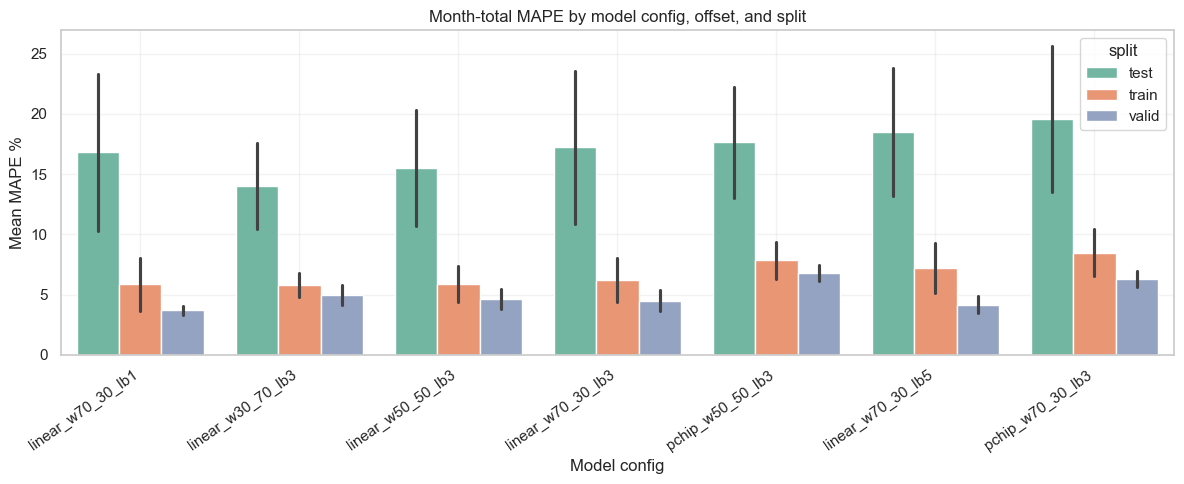

In [17]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=model_summary[model_summary["split"].isin(["train", "valid", "test"])],
    x="model_name", y="mean_mape", hue="split",
)
plt.title("Month-total MAPE by model config, offset, and split")
plt.ylabel("Mean MAPE %")
plt.xlabel("Model config")
plt.xticks(rotation=35, ha="right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Block 5：训练集、验证集、测试集 MAPE 展示

下面只展示验证集选出的 best model，并保持 train / valid / test 同一评估口径。


In [18]:
best_eval = eval_all[(eval_all["model_name"] == best_model_name) & (eval_all["forecast_offset"] == best_offset)].copy()
best_eval = best_eval.merge(
    feature_panel[["bizym", "forecast_offset", "anchor_date", "anchor_wd_seq", "max_wd_seq", "workdays"]],
    on=["bizym", "forecast_offset", "anchor_date", "anchor_wd_seq", "max_wd_seq"],
    how="left",
)
show_cols = [
    "split", "forecast_offset", "bizym", "anchor_date", "anchor_wd_seq", "max_wd_seq", "anchor_completion_pct",
    "predicted_month_total", "actual_month_total", "month_total_error_pct",
    "month_total_mape_pct", "month_total_accuracy_pct", "remaining_error_pct", "post_anchor_mtd_mape_pct",
]
best_eval[show_cols].sort_values(["bizym", "forecast_offset"])


,split,forecast_offset,bizym,anchor_date,anchor_wd_seq,max_wd_seq,anchor_completion_pct,predicted_month_total,actual_month_total,month_total_error_pct,month_total_mape_pct,month_total_accuracy_pct,remaining_error_pct,post_anchor_mtd_mape_pct
0,train,5,202401,2024-01-25,18,22,85.2576,2452309.0000,2686281.0000,-8.7099,8.7099,91.2901,-59.0806,4.3493
1,train,5,202402,2024-02-23,14,18,75.0517,1220288.0000,1223031.0000,-0.2243,0.2243,99.7757,-0.8990,2.5129
2,train,5,202403,2024-03-25,17,21,82.2660,2093776.0000,1955574.0000,7.0671,7.0671,92.9329,39.8504,5.2532
3,train,5,202404,2024-04-25,18,22,85.1281,2100796.0000,2077981.0000,1.0979,1.0979,98.9021,7.3827,1.3575
4,train,5,202405,2024-05-27,17,21,84.6421,1912583.0000,1877693.0000,1.8581,1.8581,98.1419,12.0988,0.9927
5,train,5,202406,2024-06-24,15,19,77.0092,2052465.0000,2011194.0000,2.0521,2.0521,97.9479,8.9256,2.3325
6,train,5,202407,2024-07-25,19,23,82.0150,2073906.0000,2120411.0000,-2.1932,2.1932,97.8068,-12.1947,1.6478
7,train,5,202408,2024-08-26,18,22,81.6926,2161421.0000,2158398.0000,0.1401,0.1401,99.8599,0.7650,0.8164
8,train,5,202409,2024-09-25,17,21,82.8277,2527110.0000,2538576.0000,-0.4517,0.4517,99.5483,-2.6302,1.0249
9,train,5,202410,2024-10-25,15,19,79.0730,1850233.0000,1983565.0000,-6.7218,6.7218,93.2782,-32.1204,3.9697


In [19]:
split_summary = best_eval.groupby("split").agg(
    n_months=("bizym", "nunique"),
    mean_month_total_mape=("month_total_mape_pct", "mean"),
    median_month_total_mape=("month_total_mape_pct", "median"),
    mean_accuracy=("month_total_accuracy_pct", "mean"),
    mean_remaining_error_pct=("remaining_error_pct", "mean"),
    mean_post_anchor_mtd_mape=("post_anchor_mtd_mape_pct", "mean"),
).reset_index()
split_summary


,split,n_months,mean_month_total_mape,median_month_total_mape,mean_accuracy,mean_remaining_error_pct,mean_post_anchor_mtd_mape
0,test,4,10.3232,7.3867,89.6768,16.5585,6.6875
1,train,12,3.6680,2.1226,96.3320,-9.7996,2.6737
2,valid,12,3.2941,3.0119,96.7059,1.3561,1.9131


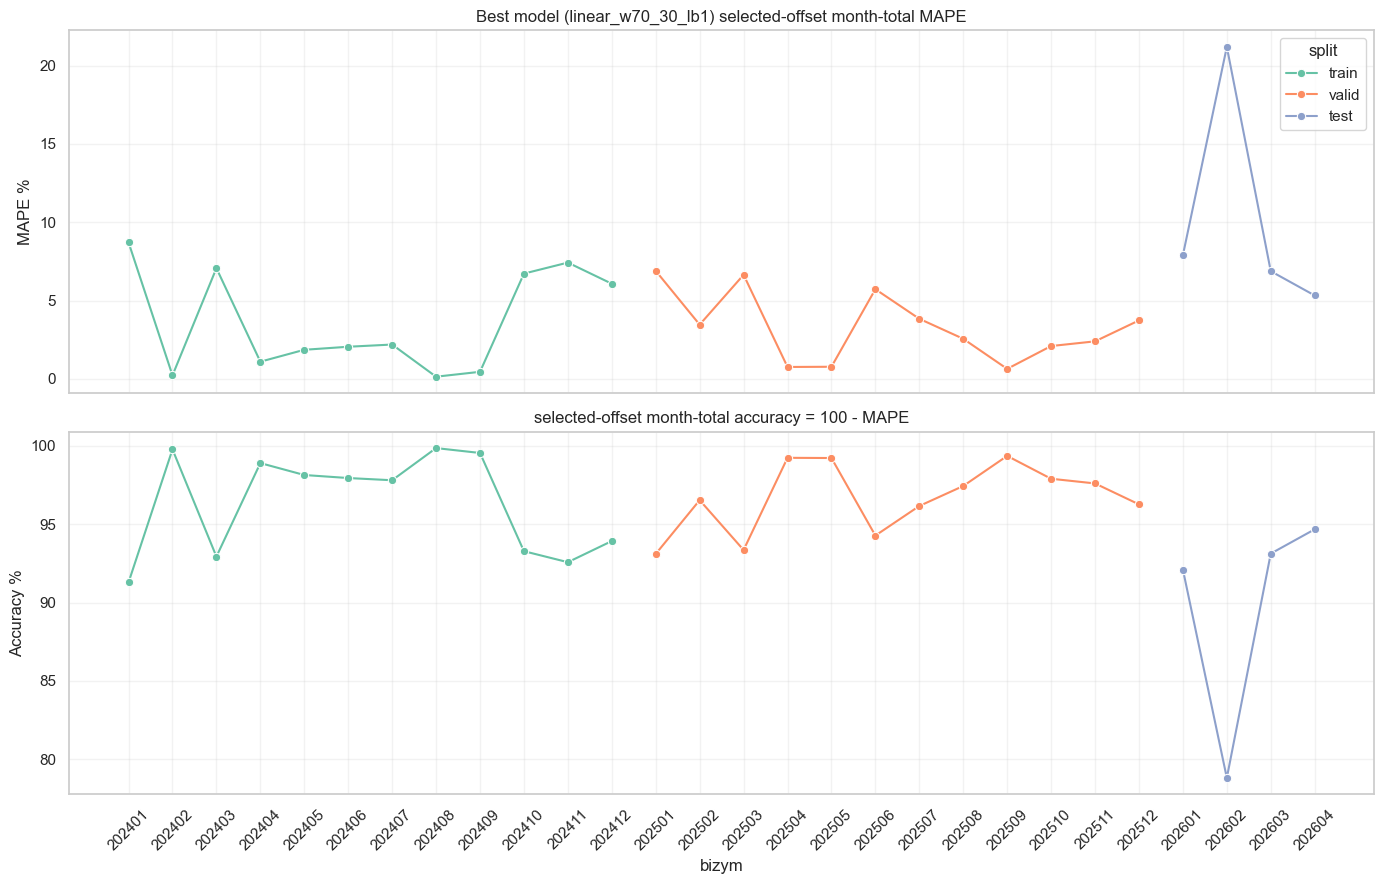

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

plot_df = best_eval.sort_values("bizym").copy()
plot_df["bizym_str"] = plot_df["bizym"].astype(str)

sns.lineplot(
    data=plot_df,
    x="bizym_str",
    y="month_total_mape_pct",
    hue="split",
    marker="o",
    ax=axes[0],
)
axes[0].set_title(f"Best model ({best_model_name}) selected-offset month-total MAPE")
axes[0].set_ylabel("MAPE %")

sns.lineplot(
    data=plot_df,
    x="bizym_str",
    y="month_total_accuracy_pct",
    hue="split",
    marker="o",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("selected-offset month-total accuracy = 100 - MAPE")
axes[1].set_ylabel("Accuracy %")
axes[1].set_xlabel("bizym")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

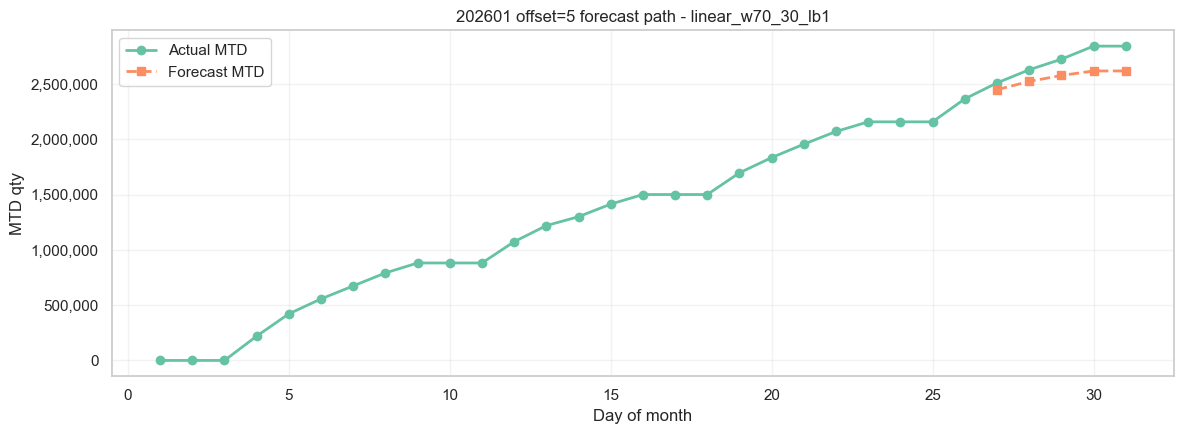

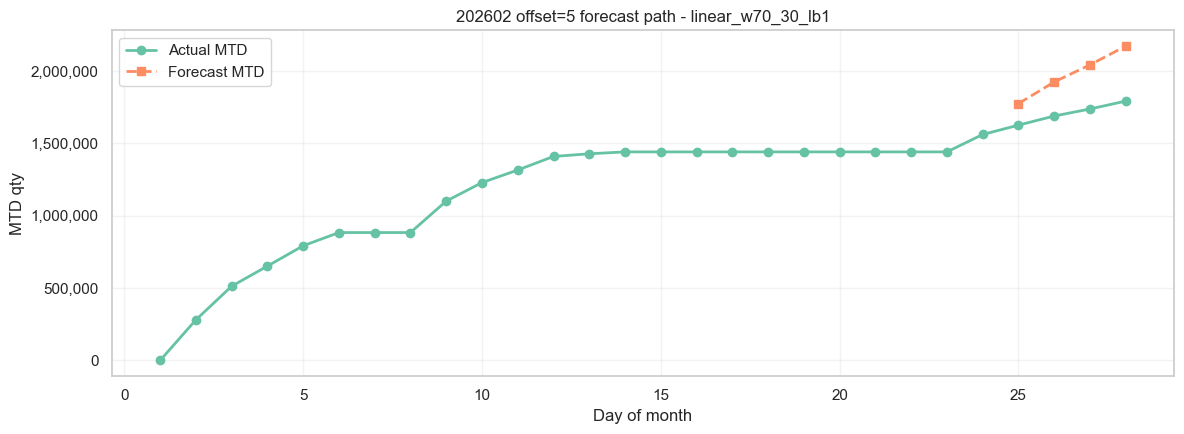

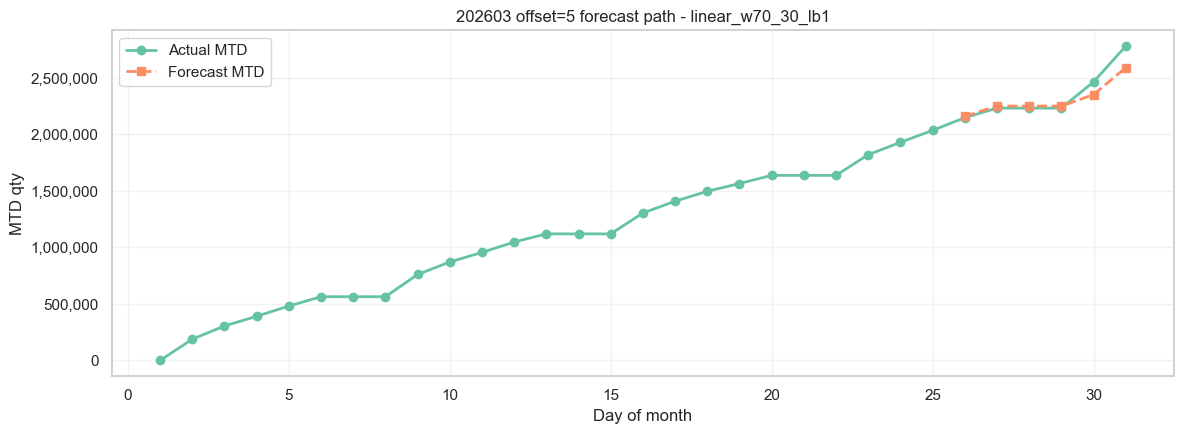

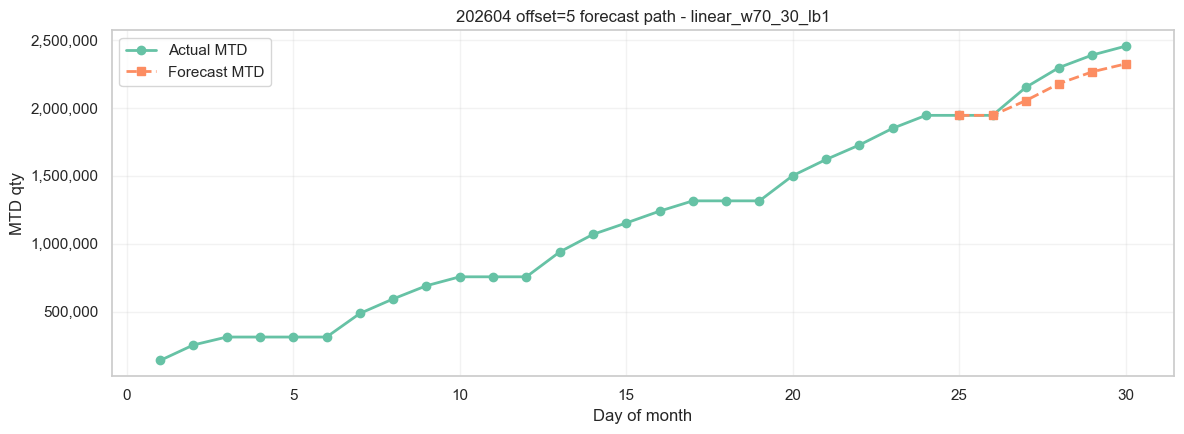

In [21]:
def plot_forecast_path(data: pd.DataFrame, forecast_df: pd.DataFrame, target_ym: int, title: str) -> None:
    actual = data[data["bizym"] == int(target_ym)][["transdate", "day_of_month", "mtd_qty"]].copy()
    merged = actual.merge(forecast_df[["transdate", "predicted_mtd_qty"]], on="transdate", how="left")
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(merged["day_of_month"], merged["mtd_qty"], marker="o", linewidth=2, label="Actual MTD")
    ax.plot(merged["day_of_month"], merged["predicted_mtd_qty"], marker="s", linestyle="--", linewidth=2, label="Forecast MTD")
    ax.set_title(title)
    ax.set_xlabel("Day of month")
    ax.set_ylabel("MTD qty")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

for ym in sorted(best_eval.loc[best_eval["split"] == "test", "bizym"]):
    plot_forecast_path(
        df,
        forecast_store[(best_model_name, int(ym), best_offset)],
        int(ym),
        f"{ym} offset={best_offset} forecast path - {best_model_name}",
    )


## Block 6：误差分析与误差 insight

这里不做 root cause，只把误差和可观察条件做切片，形成后续实验线索。


In [22]:
def add_error_slices(eval_df: pd.DataFrame) -> pd.DataFrame:
    out = eval_df.copy()
    out["abs_error_pct"] = out["month_total_mape_pct"]
    out["signed_error_direction"] = np.where(out["month_total_error_pct"] >= 0, "over_forecast", "under_forecast")
    out["completion_bucket"] = pd.cut(
        out["anchor_completion_pct"],
        bins=[0, 60, 70, 80, 90, 100, np.inf],
        labels=["<=60%", "60-70%", "70-80%", "80-90%", "90-100%", ">100%"],
        include_lowest=True,
    )
    out["workday_count_bucket"] = pd.cut(
        out["workdays"], bins=[0, 19, 20, 21, 22, 40], labels=["<=19", "20", "21", "22", ">=23"], include_lowest=True
    )
    out["month_num"] = out["bizym"] % 100
    out["season"] = np.select(
        [out["month_num"].isin([12, 1, 2]), out["month_num"].isin([3, 4, 5]), out["month_num"].isin([6, 7, 8]), out["month_num"].isin([9, 10, 11])],
        ["winter", "spring", "summer", "autumn"],
        default="unknown",
    )
    return out


def summarize_slice(df_slice: pd.DataFrame, col: str) -> pd.DataFrame:
    return df_slice.groupby(col, dropna=False).agg(
        n_months=("bizym", "nunique"),
        mean_mape=("abs_error_pct", "mean"),
        median_mape=("abs_error_pct", "median"),
        over_forecast_rate=("signed_error_direction", lambda s: (s == "over_forecast").mean() * 100),
    ).reset_index().sort_values("mean_mape", ascending=False)

error_df = add_error_slices(best_eval)
error_df[["split", "forecast_offset", "bizym", "abs_error_pct", "signed_error_direction", "completion_bucket", "workday_count_bucket", "season"]].sort_values("abs_error_pct", ascending=False).head(12)


,split,forecast_offset,bizym,abs_error_pct,signed_error_direction,completion_bucket,workday_count_bucket,season
25,test,5,202602,21.1940,over_forecast,80-90%,<=19,winter
0,train,5,202401,8.7099,under_forecast,80-90%,22,winter
24,test,5,202601,7.8978,under_forecast,80-90%,21,winter
10,train,5,202411,7.4249,under_forecast,80-90%,21,autumn
2,train,5,202403,7.0671,over_forecast,80-90%,21,spring
12,valid,5,202501,6.8969,over_forecast,90-100%,<=19,winter
26,test,5,202603,6.8757,under_forecast,70-80%,22,spring
9,train,5,202410,6.7218,under_forecast,70-80%,<=19,autumn
14,valid,5,202503,6.6449,under_forecast,70-80%,21,spring
11,train,5,202412,6.0750,under_forecast,80-90%,22,winter


In [23]:
for slice_col in ["split", "completion_bucket", "workday_count_bucket", "season", "signed_error_direction"]:
    print(f"\n=== Error slice: {slice_col} ===")
    display(summarize_slice(error_df, slice_col))



=== Error slice: split ===


,split,n_months,mean_mape,median_mape,over_forecast_rate
0,test,4,10.3232,7.3867,25.0000
1,train,12,3.6680,2.1226,41.6667
2,valid,12,3.2941,3.0119,41.6667



=== Error slice: completion_bucket ===


,completion_bucket,n_months,mean_mape,median_mape,over_forecast_rate
4,90-100%,1,6.8969,6.8969,100.0000
2,70-80%,9,4.5411,5.3254,22.2222
3,80-90%,18,4.2818,2.2950,44.4444
0,<=60%,0,NaN,NaN,NaN
1,60-70%,0,NaN,NaN,NaN
5,>100%,0,NaN,NaN,NaN



=== Error slice: workday_count_bucket ===


,workday_count_bucket,n_months,mean_mape,median_mape,over_forecast_rate
0,<=19,8,5.4281,2.7806,62.5000
2,21,8,4.9038,5.9852,37.5000
1,20,2,4.0611,4.0611,0.0000
3,22,6,3.9432,3.5865,33.3333
4,>=23,4,2.6005,2.9632,25.0000



=== Error slice: season ===


,season,n_months,mean_mape,median_mape,over_forecast_rate
3,winter,8,7.2743,6.4859,37.5000
1,spring,8,3.8005,3.5918,37.5000
0,autumn,6,3.2887,2.2472,33.3333
2,summer,6,2.7512,2.3767,50.0000



=== Error slice: signed_error_direction ===


,signed_error_direction,n_months,mean_mape,median_mape,over_forecast_rate
0,over_forecast,11,4.4606,2.0975,100.0000
1,under_forecast,17,4.4571,5.3254,0.0000


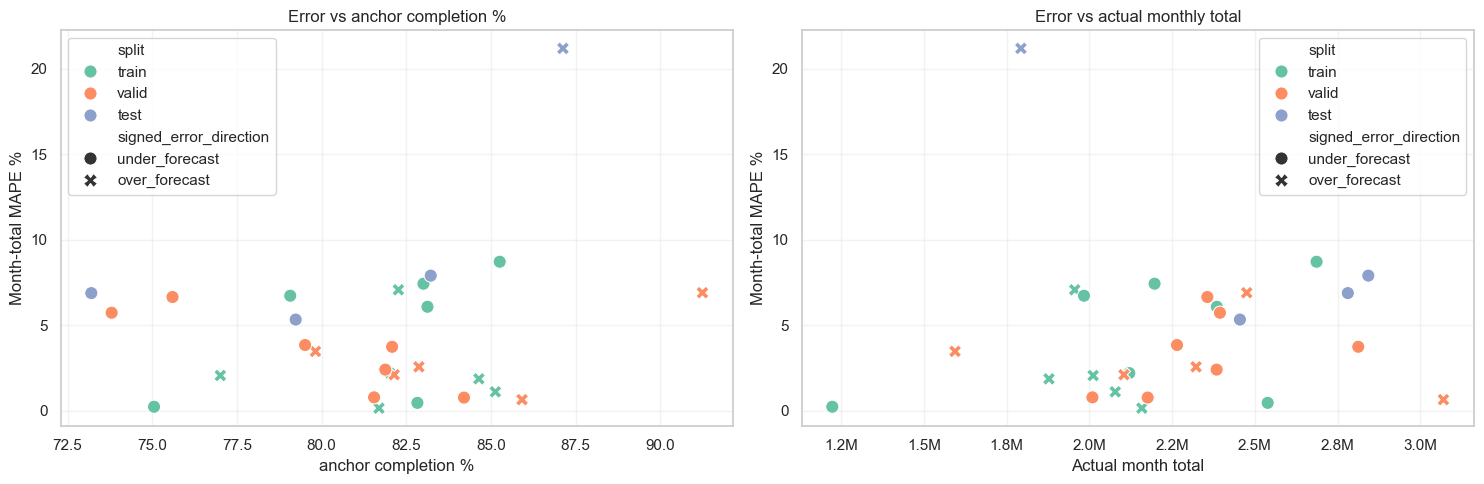

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=error_df, x="anchor_completion_pct", y="abs_error_pct", hue="split", style="signed_error_direction", s=90, ax=axes[0])
axes[0].set_title("Error vs anchor completion %")
axes[0].set_xlabel("anchor completion %")
axes[0].set_ylabel("Month-total MAPE %")
sns.scatterplot(data=error_df, x="actual_month_total", y="abs_error_pct", hue="split", style="signed_error_direction", s=90, ax=axes[1])
axes[1].set_title("Error vs actual monthly total")
axes[1].set_xlabel("Actual month total")
axes[1].set_ylabel("Month-total MAPE %")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [25]:
high_error_threshold = error_df["abs_error_pct"].quantile(0.75)
low_error_threshold = error_df["abs_error_pct"].quantile(0.25)
high_error = error_df[error_df["abs_error_pct"] >= high_error_threshold].copy()
low_error = error_df[error_df["abs_error_pct"] <= low_error_threshold].copy()

insights = []
insights.append(f"High-error threshold (top quartile) = {high_error_threshold:.2f}% MAPE; low-error threshold (bottom quartile) = {low_error_threshold:.2f}% MAPE.")
insights.append(f"High-error months are mostly: {', '.join(map(str, high_error.sort_values('abs_error_pct', ascending=False)['bizym'].head(8).tolist()))}.")
insights.append(f"Low-error months are mostly: {', '.join(map(str, low_error.sort_values('abs_error_pct')['bizym'].head(8).tolist()))}.")

for col, label in [("completion_bucket", "anchor completion bucket"), ("workday_count_bucket", "workday count"), ("season", "season"), ("signed_error_direction", "forecast direction")]:
    summary = summarize_slice(error_df, col)
    top = summary.iloc[0]
    insights.append(f"Largest average error by {label}: {top[col]} with {top['mean_mape']:.2f}% mean MAPE over {int(top['n_months'])} months.")

print("误差 insights:")
for i, item in enumerate(insights, start=1):
    print(f"{i}. {item}")


误差 insights:
1. High-error threshold (top quartile) = 6.76% MAPE; low-error threshold (bottom quartile) = 1.67% MAPE.
2. High-error months are mostly: 202602, 202401, 202601, 202411, 202403, 202501, 202603.
3. Low-error months are mostly: 202408, 202402, 202409, 202509, 202504, 202505, 202404.
4. Largest average error by anchor completion bucket: 90-100% with 6.90% mean MAPE over 1 months.
5. Largest average error by workday count: <=19 with 5.43% mean MAPE over 8 months.
6. Largest average error by season: winter with 7.27% mean MAPE over 8 months.
7. Largest average error by forecast direction: over_forecast with 4.46% mean MAPE over 11 months.


## Reproducibility Notes

- 数据契约：`bizym/transdate/num_hosp/qty`，日粒度，目标为月末 `qty` 总量。
- 防泄漏：每个目标月只使用锚点当天及之前的目标月 MTD，以及前 1/2 年同月完整历史节奏。
- 主指标：配置的预测 offset 锚点的月末总量 MAPE；accuracy 仅为 `100 - MAPE` 的展示口径。
- Oracle 拆解：若需要进一步诊断，可用 `decompose_from_month_total` 输入真实月末总量评估节奏拆解上限，但不得参与模型选择。
